In [20]:
import os
import numpy as np 
import pandas as pd 
import transition as tr
import segmentation as sg
import adjective_mean as am
import validation_model as vm
import dbscan_clustering as db
import data_processing.src.plot as plot

from data_processing.src import config

In [21]:
target_activity = "sphereActivity"
threshold = 0.6
scaler = "standard"

# only rotation
"""result_directory = "dbscan_results_rotation"
features = config.ROTATION_FEATURES
segmentation_result = config.ROTATION_SEGMENTATION_DIR 
processed_data_path = config.PROCESSED_DATA_DIR
histogram_dir = config.ROTATION_HISTOGRAMS_DIR"""

# only position
"""result_directory = "dbscan_results_position"
features = config.POSITION_FEATURES
segmentation_result = config.POSITION_SEGMENTATION_DIR 
processed_data_path = config.PROCESSED_DATA_DIR
histogram_dir = config.POSITION_HISTOGRAMS_DIR"""

# both rotation and position
result_directory = "dbscan_results"
features = config.FEATURES
segmentation_result = config.BOTH_SEGMENTATION_DIR 
processed_data_path = config.PROCESSED_DATA_DIR
histogram_dir = config.BOTH_HISTOGRAMS_DIR

# Training del Modello

## 1 Segmentazione della Target Activity

===== Processing user: grims2, act: sphereActivity, scaler: standard, threshold: 0.6 =====
Data successfully loaded - Shape: (10357, 22)
Rotation features normalized
Position features normalized
===== Processing user: pedro, act: sphereActivity, scaler: standard, threshold: 0.6 =====
Data successfully loaded - Shape: (13087, 22)
Rotation features normalized
Position features normalized
No data found for log number 2
===== Processing user: xxx, act: sphereActivity, scaler: standard, threshold: 0.6 =====
Data successfully loaded - Shape: (18484, 22)
Rotation features normalized
Position features normalized
===== Processing user: slasto, act: sphereActivity, scaler: standard, threshold: 0.6 =====
Data successfully loaded - Shape: (29147, 22)
Rotation features normalized
Position features normalized
No data found for log number 1
No data found for log number 5
===== Processing user: minestra, act: sphereActivity, scaler: standard, threshold: 0.6 =====
Data successfully loaded - Shape: (206

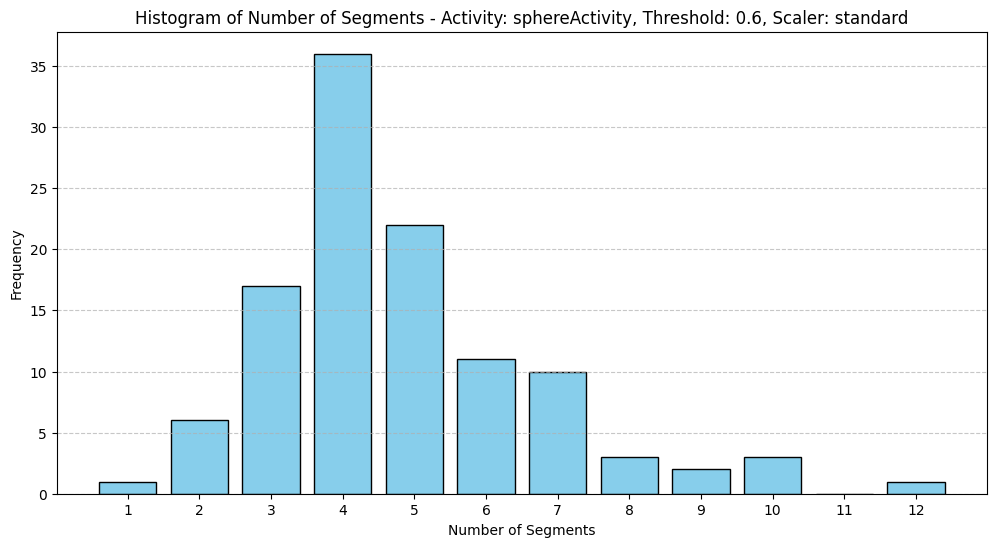

In [22]:
rsv_df = sg.segment_all_users(
            activity=target_activity, 
            features=features,
            threshold=threshold, 
            scaler=scaler, 
            filepath=segmentation_result
        )

os.makedirs(segmentation_result + f"/segments_number/{target_activity}", exist_ok=True)
os.makedirs(histogram_dir + f"/{target_activity}", exist_ok=True)

plot.plot_histogram_of_segments(
    filepath=segmentation_result + f"/segments_number/{target_activity}/{scaler}/segmentation_results_{target_activity}_{threshold}_{scaler}.csv",
    savepath=histogram_dir + f"/{target_activity}")


## 2 Clustering delle Azioni Elementari 

In [23]:
rsv_path = segmentation_result + f"/right_singular_vector/{target_activity}/{scaler}/rsv_{target_activity}_{threshold}_{scaler}.csv"

In [24]:
print(f"===== Processing activity: {target_activity}, threshold: {threshold}, scaler: {scaler} =====\n")

df_origin = pd.read_csv(rsv_path, index_col=None)

df = df_origin.drop(columns=['Username', 'Adjective', 'LogNumber'])
df = df.dropna()

n_cols = len(df.columns)
length = len(df)
print("=================================================\n")

===== Processing activity: sphereActivity, threshold: 0.6, scaler: standard =====




### 2.1 Grafici Iniziali 

== Heatmap of Features ==



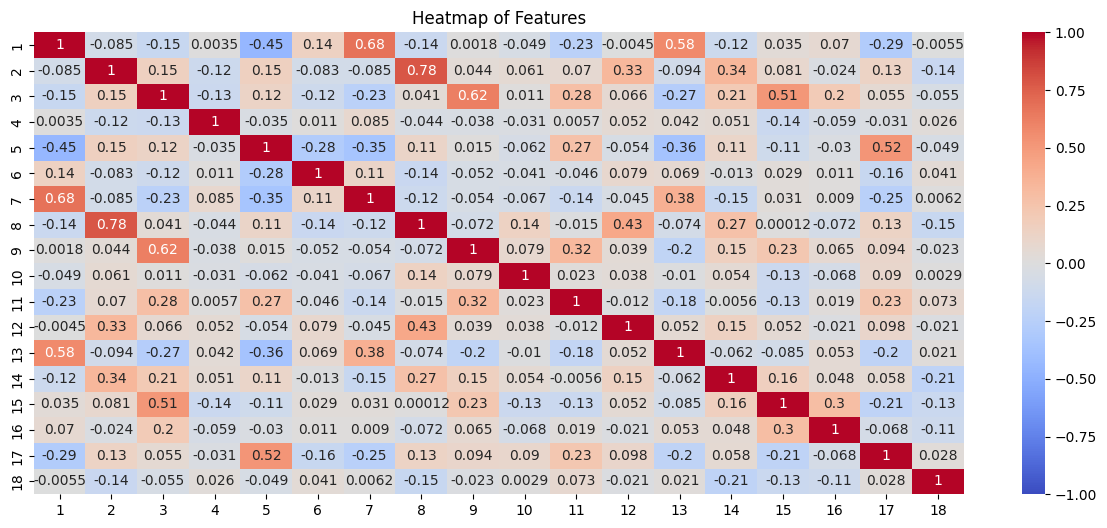

== Box Plot of Features ==



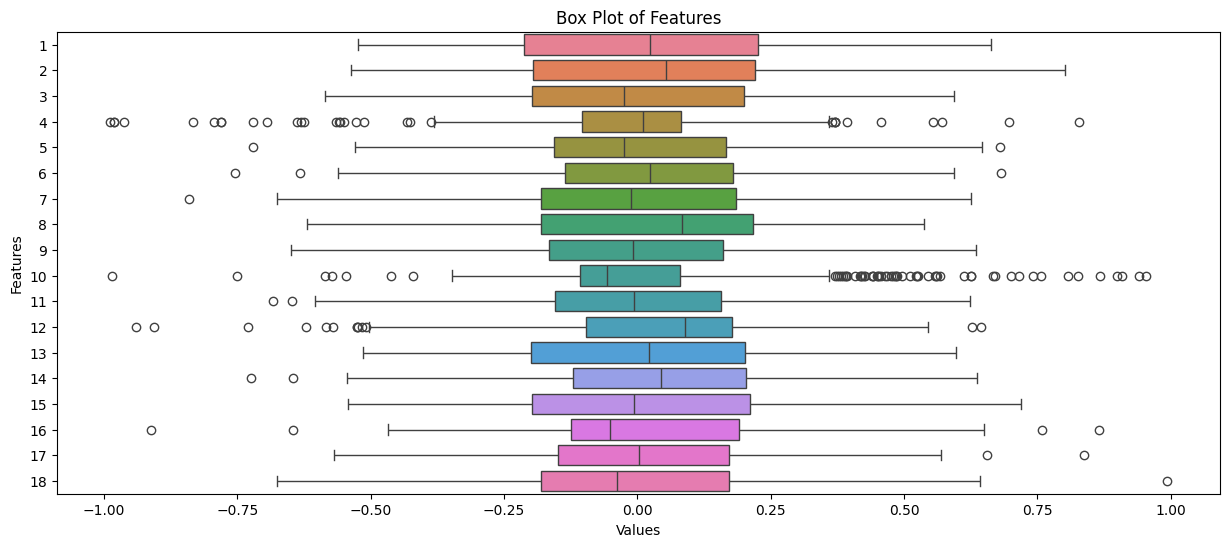

In [25]:
db.initial_plot(df)

### 2.2 GRID per Iperparametri 

== DBSCAN Clustering Results ==

Number of columns: 18
Length of DataFrame: 538

 ITER| INFO                                        | CLUS    OUT   |   Cluster Size
------------------------------------------------------------------------------------
   1 | Tested with eps = 0.1 and min_samples =   3 |  26     400   | C0: 15, C1: 11, C2: 3, C3: 4, C4: 4, C5: 5, C6: 3, C7: 6, C8: 3, C9: 5, C10: 3, C11: 3, C12: 3, C13: 3, C14: 12, C15: 7, C16: 4, C17: 9, C18: 3, C19: 7, C20: 4, C21: 9, C22: 3, C23: 3, C24: 3, C25: 3
   2 | Tested with eps = 0.1 and min_samples =   4 |  12     450   | C0: 15, C1: 10, C2: 4, C3: 5, C4: 10, C5: 5, C6: 4, C7: 9, C8: 7, C9: 4, C10: 9, C11: 6
   3 | Tested with eps = 0.1 and min_samples =   5 |   8     470   | C0: 15, C1: 10, C2: 5, C3: 9, C4: 9, C5: 5, C6: 9, C7: 6
   4 | Tested with eps = 0.1 and min_samples =   6 |   6     484   | C0: 15, C1: 10, C2: 6, C3: 9, C4: 8, C5: 6
   5 | Tested with eps = 0.1 and min_samples =   7 |   4     497   | C0: 15, C1: 9, C2

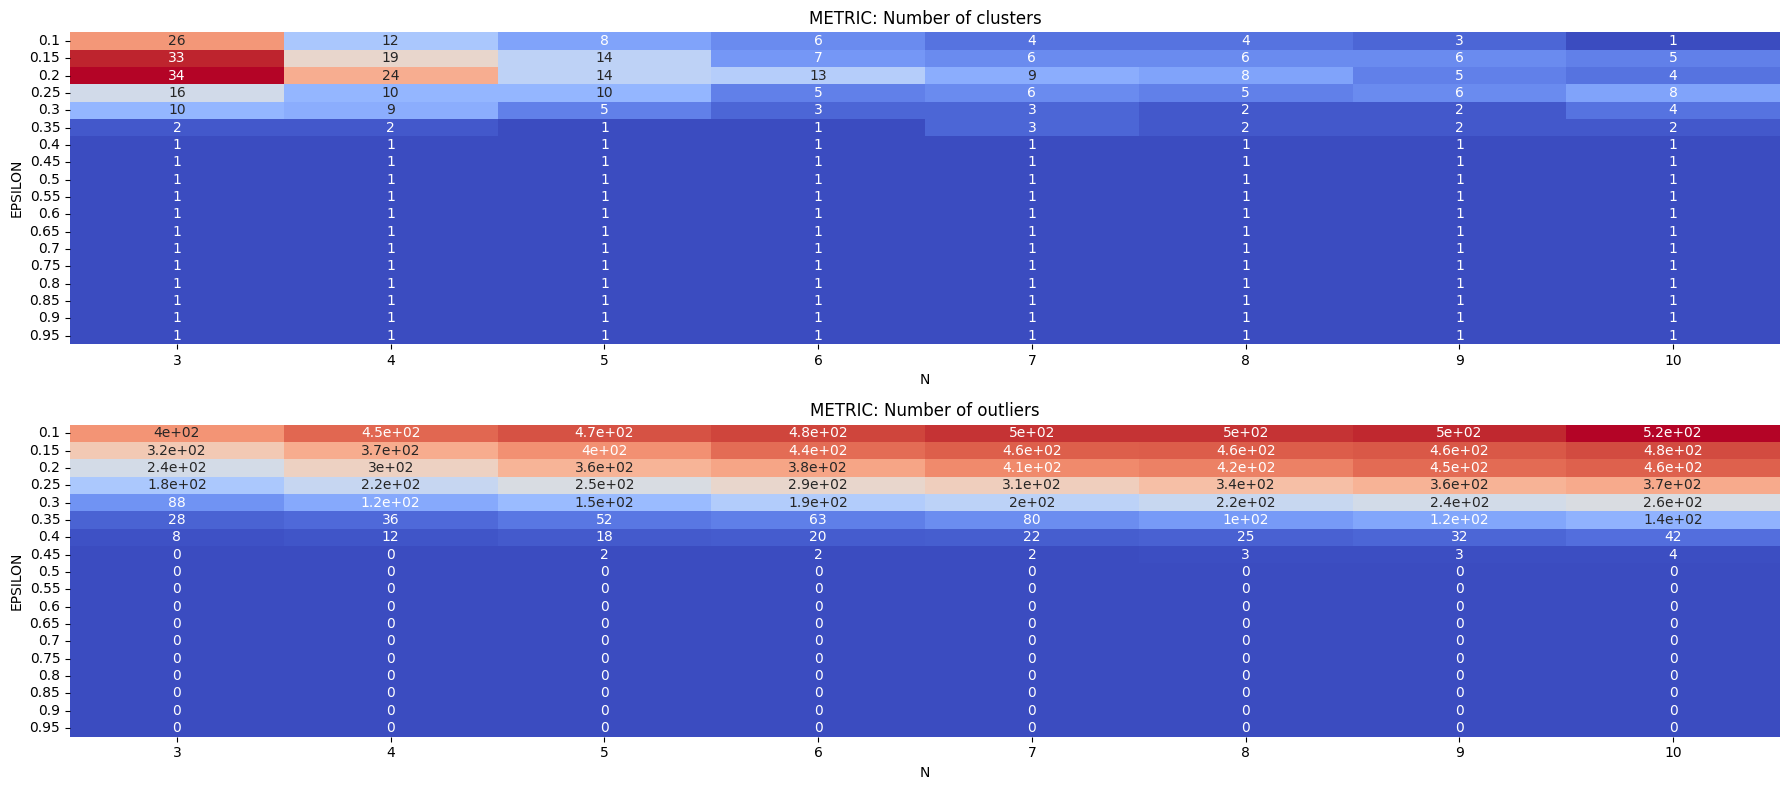

In [26]:
print("== DBSCAN Clustering Results ==\n")
print(f"Number of columns: {n_cols}\nLength of DataFrame: {length}\n")
db.grid(df)

### 2.3 Scelta Iperparametri del Clustering 

In [27]:
eps = 0.3
min_samples = 10

In [28]:
best_labels = db.dbscan_clustering(df, eps=eps, min_samples=min_samples)
df['Label'] = best_labels

# Insert Label column after LogNumber column in df_origin
lognumber_index = df_origin.columns.get_loc('LogNumber')
df_origin.insert(lognumber_index + 1, 'Label', best_labels)

save_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/all_points/dbscan_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"

os.makedirs(os.path.dirname(save_dir), exist_ok=True)
df_origin.to_csv(save_dir, index=False)

df_no_outliers = df.drop(df[df['Label'] == -1].index)
unique_labels = df_no_outliers['Label'].unique()

print(f"Number of unique labels (excluding outliers): {len(unique_labels)}\n")

Number of unique labels (excluding outliers): 4



### 2.4 Stampa e Salvataggio dei risultati.

In [29]:
df_substantives = db.get_substantives_dataframe(df=df_no_outliers, unique_labels=unique_labels)
print("\n== Substantives DataFrame ==\n")
display(df_substantives)

save_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/substantives/substantives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
os.makedirs(os.path.dirname(save_dir), exist_ok=True)

df_substantives.to_csv(processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/substantives/substantives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv", index=False)

df_adjectives = db.get_adjectives_dataframe(df=df_origin, unique_labels=unique_labels)
print("\n== Adjectives DataFrame ==\n")
display(df_adjectives)

save_dir = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}/adjectives/"
os.makedirs(os.path.dirname(save_dir), exist_ok=True)

df_adjectives.to_csv(save_dir + f"adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv", index=False)




== Substantives DataFrame ==



,Label,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0,0.270908,-0.026007,-0.133205,0.022401,-0.169725,0.071969,0.244111,-0.034274,-0.080096,-0.024065,-0.106385,0.057652,0.214137,-0.021016,0.046307,0.048174,-0.118153,-0.003233
1,1,-0.225860,0.161468,0.117236,-0.042589,0.187162,-0.076857,-0.179609,0.154984,0.016341,0.073508,0.098078,0.107390,-0.195901,0.099613,0.044306,0.020836,0.140885,0.000242
2,3,-0.249101,0.351781,-0.194617,-0.181805,-0.096021,0.017901,-0.100115,0.373893,-0.112522,0.458903,-0.059725,0.101780,-0.177450,-0.065565,-0.057105,-0.019032,0.010043,-0.016899
3,2,0.082246,-0.181364,0.024927,-0.781130,0.026444,-0.007979,-0.070132,-0.182486,0.026277,-0.007114,0.038293,-0.123047,0.014469,-0.038517,0.049061,0.004740,0.046072,0.057902



== Adjectives DataFrame ==



,Label,Adjective
0,0,0.036711
1,0,0.000808
2,0,0.002460
3,0,0.003876
4,0,0.005380
...,...,...
278,2,0.012427
279,2,0.000626
280,2,0.002307
281,2,0.002179


## 2.5 Gestione degli Aggetivi

In [30]:
adj_selection = "percentile"
# adj_selection = "min_mean_max"

os.makedirs(save_dir + "mean/", exist_ok=True)

if(adj_selection == "min_mean_max"):
    print("\n== Mean Adjectives DataFrame (Min-Mean-Max) ==\n")
    summary_df = am.mean_adjectives(
        filepath=save_dir + f"/adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv", 
        dbscan_results=result_directory,
        activity=target_activity,
        scaler=scaler,
        save_path=save_dir + f"/mean/mean_adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv"
    )
elif(adj_selection == "percentile"):
    print("\n== Mean Adjectives DataFrame (Percentile) ==\n")
    summary_df = am.percentile_adjectives(
        filepath=save_dir + f"/adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv", 
        dbscan_results=result_directory,
        activity=target_activity,
        scaler=scaler,
    save_path=save_dir + f"/mean/mean_adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv")


print("\n== Mean Adjectives DataFrame ==\n")
display(summary_df)


== Mean Adjectives DataFrame (Percentile) ==


== Mean Adjectives DataFrame ==



,Label,Adjective
0,0,0.000777
1,0,0.003123
2,0,-0.001815
3,0,-0.000292
4,1,0.000924
5,1,0.004644
6,1,-0.002938
7,1,-0.000561
8,2,0.002307
9,2,0.007735


## 3. Transizioni di Stato


== Transition Matrix: ==


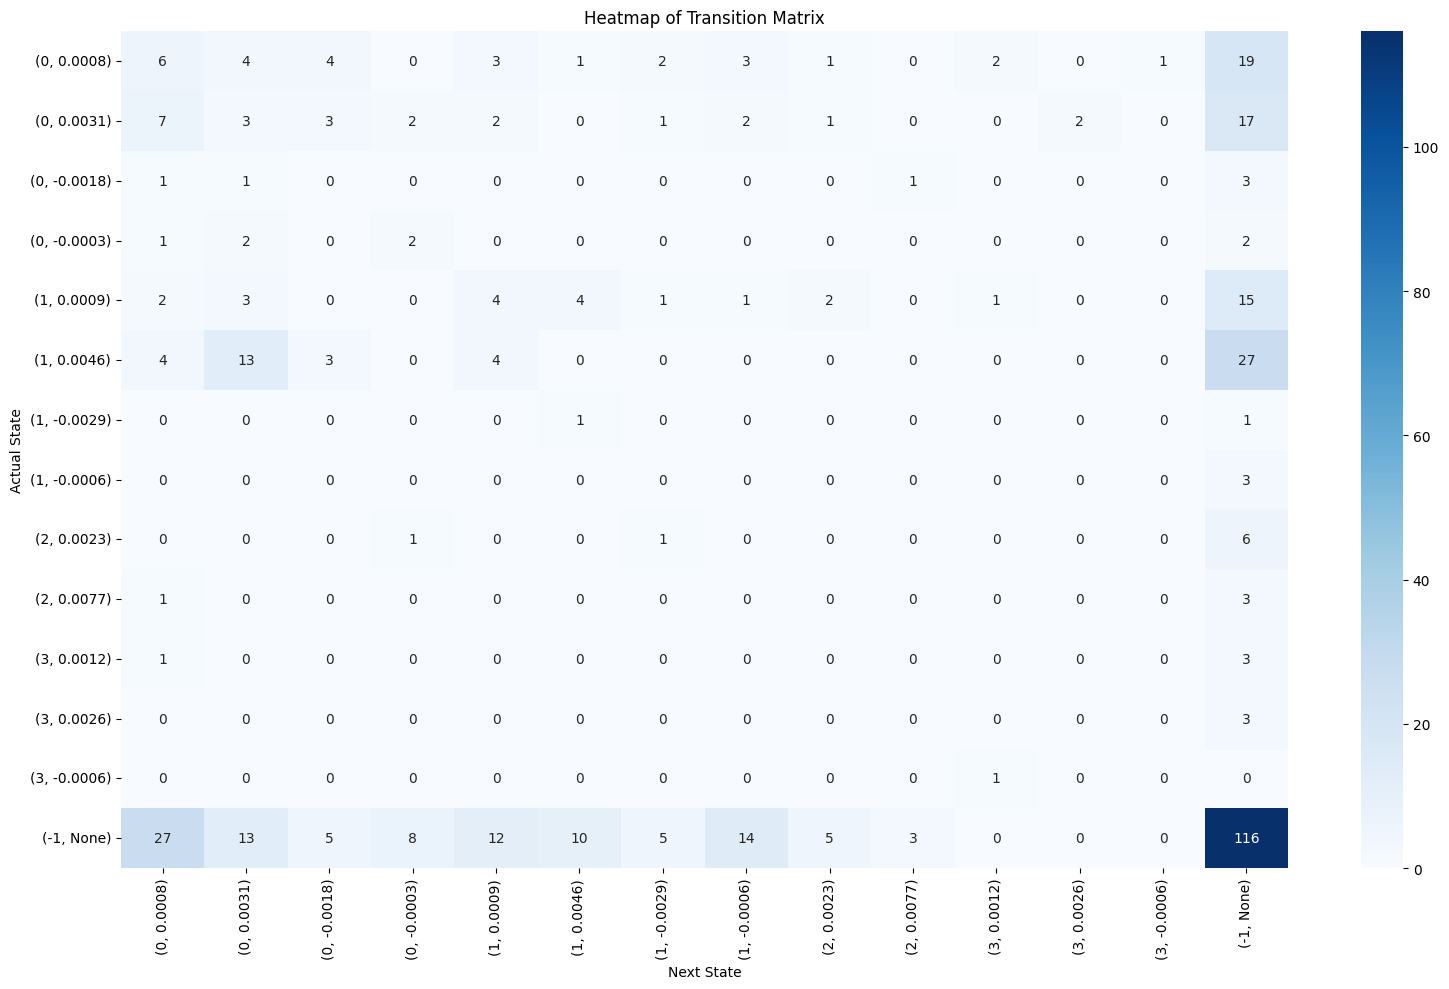


== Transition Probabilities: ==


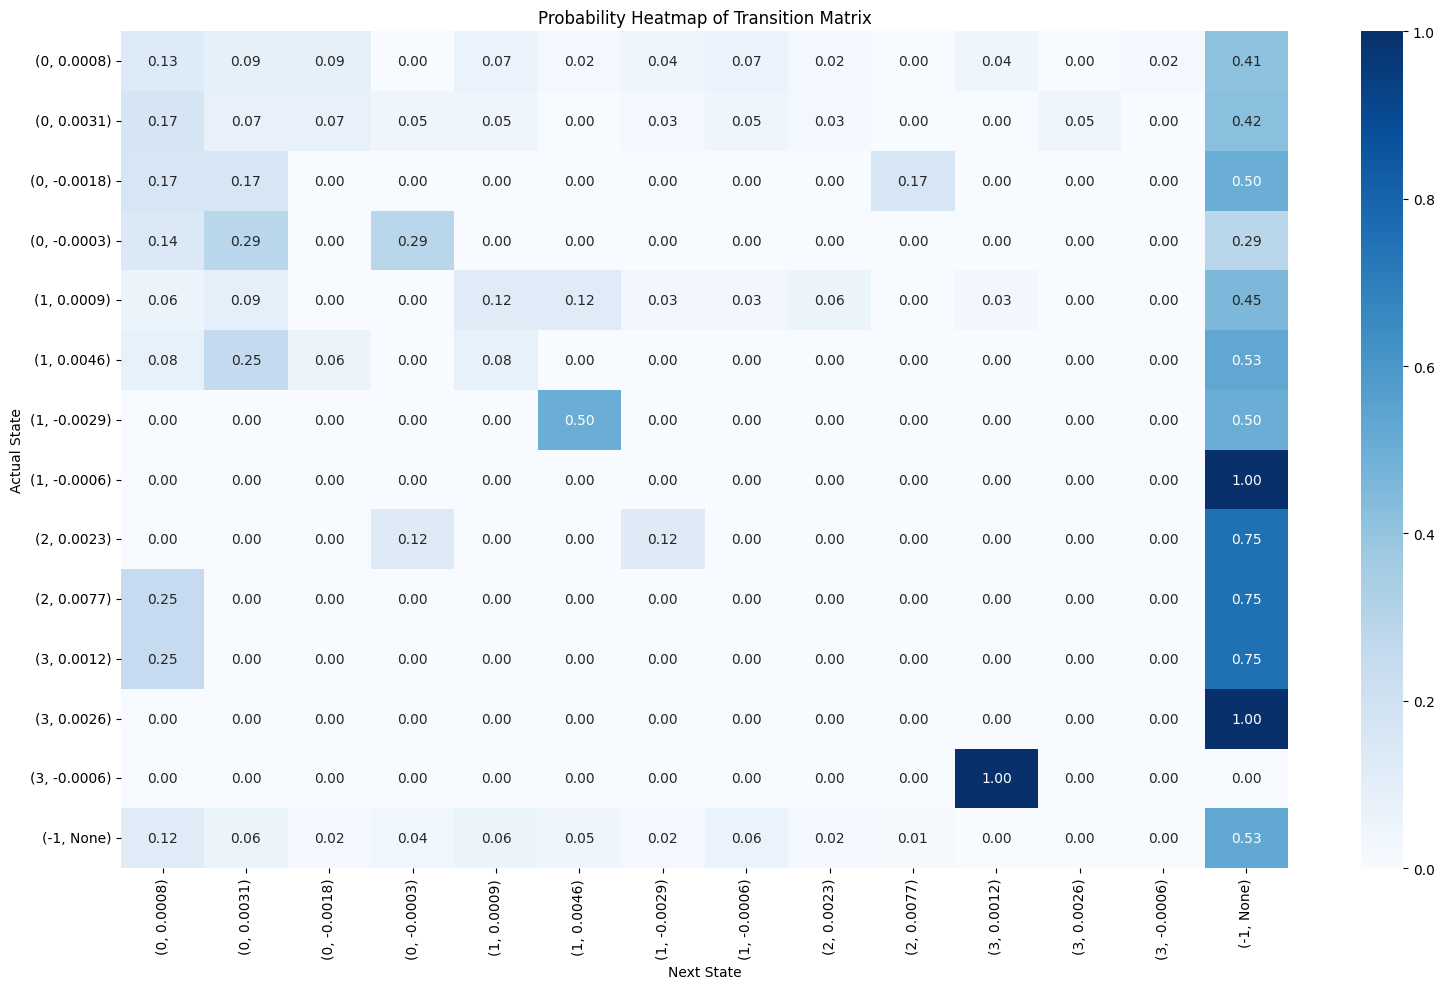


Transition results saved in /Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/results/transition_results/sphereActivity/standard


,State,Initial_Probability
0,"(0, 0.0008)",0.107143
1,"(0, 0.0031)",0.062500
2,"(0, -0.0018)",0.000000
3,"(0, -0.0003)",0.008929
4,"(1, 0.0009)",0.151786
5,"(1, 0.0046)",0.321429
6,"(1, -0.0029)",0.008929
7,"(1, -0.0006)",0.000000
8,"(2, 0.0023)",0.000000
9,"(2, 0.0077)",0.000000


In [31]:
_, _, df_initial = tr.transition_computation(
        activity=target_activity,
        scaler=scaler,
        threshold=threshold,
        eps=eps,
        min_samples=min_samples,
        dbscan_results=result_directory,
        file_path=processed_data_path + f"/{result_directory}/{target_activity}/{scaler}"
    )

display(df_initial)

# Validation del Modello

In [46]:
username = "grims3"
test_activity = "trashActivity"

#file_path = config.find_file_from_username(username)
file_path = config.find_file_from_username_and_basepath(username=username, base_path=config.RAW_DATA_DIR + "/test_data")
print(file_path)

/Users/grims/Documents/Research/Tesi/ML_tesi/data_logs/raw/test_data/grims3/grims3_log_20250719_1247_3L2OXWTATJ.csv


## 1. Segmentazione della Test Activity dell'Utente

In [47]:
new_threshold = 0.5

print(f"===== Segmentating user: {username}, test_activity: {test_activity}, scaler: {scaler}, threshold: {new_threshold} =====")
rsv_df = vm.segment_user(file_path=file_path, features=features, activity=test_activity, scaler=scaler, threshold=new_threshold)

print("\n== RSV DataFrame: ==")
display(rsv_df)


===== Segmentating user: grims3, test_activity: trashActivity, scaler: standard, threshold: 0.5 =====
Data successfully loaded - Shape: (8919, 22)
Rotation features normalized
Position features normalized

== RSV DataFrame: ==


,Adjective,LogNumber,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,-0.006132,1.0,-0.125449,0.357853,0.151702,-0.366357,-0.206584,-0.240972,-0.289310,0.047797,0.209265,-0.528034,0.062186,0.094155,-0.183314,-0.097264,-0.088372,0.088918,0.216525,-0.266901
1,-0.000729,1.0,-0.157299,0.462799,0.199387,-0.463752,0.069622,-0.140044,-0.132020,0.348311,0.200449,0.078551,0.220948,-0.000397,-0.184302,-0.122228,0.080665,0.088065,0.295371,-0.312191
2,-0.000087,1.0,0.273262,-0.230557,-0.137825,0.164122,-0.432212,-0.397948,0.395757,-0.149755,-0.283926,-0.078677,-0.184811,-0.092609,0.176346,-0.000614,0.169470,-0.048126,-0.204356,0.261893
3,-0.027242,1.0,-0.093182,0.220776,0.094806,-0.347391,-0.053025,-0.154913,-0.108856,0.242957,0.159902,0.041017,0.135033,0.783745,-0.078495,0.018632,-0.010415,0.014560,0.156437,-0.155488
4,-0.000450,1.0,0.196654,0.368726,-0.024892,-0.495997,-0.216013,-0.221986,0.316311,0.167017,0.181725,0.088891,-0.343633,-0.117664,0.137084,0.123318,0.143897,0.005329,0.273180,-0.229420
5,-0.000823,1.0,-0.218456,0.176496,0.064697,-0.264076,0.095753,-0.072033,-0.093589,0.028570,0.305685,0.242006,0.187875,0.041672,-0.408449,0.516630,-0.141834,0.378856,0.090384,-0.169331
6,0.002614,1.0,-0.270636,0.229059,-0.123912,-0.228758,0.174323,-0.209500,-0.152064,-0.069440,0.092510,-0.070265,0.062551,0.062718,-0.400073,0.630419,-0.134872,-0.129016,0.169292,-0.249112
7,-0.003436,1.0,-0.213358,0.296771,-0.297989,-0.181121,0.171167,-0.262466,-0.185771,0.146285,-0.183770,-0.075556,-0.061238,0.045793,-0.265136,0.467632,-0.417988,0.098648,0.181917,-0.197135
8,0.003086,1.0,-0.188212,0.153589,-0.049983,-0.166272,0.073358,0.015046,-0.114283,-0.051744,0.197314,0.011002,0.180968,0.031975,-0.256632,0.491326,-0.369712,0.581951,0.107611,-0.149918
9,0.002933,1.0,-0.288655,0.330144,0.091004,-0.300591,0.084475,-0.000046,-0.084014,-0.008319,0.287331,-0.065911,0.149633,0.064945,-0.484260,0.532059,0.098328,-0.060982,0.096450,-0.202456


In [48]:
for x in range(1, len(rsv_df['LogNumber'].unique()) + 1):
    print(f"LogNumber: {x}, Number of segments: {len(rsv_df[rsv_df['LogNumber'] == x])}")

LogNumber: 1, Number of segments: 18
LogNumber: 2, Number of segments: 16
LogNumber: 3, Number of segments: 17


## 2. Maximum Likelihood Classifier

### 2.1 Classifica le Nuove Elementary Action 

In [49]:
file_path = processed_data_path + f"/{result_directory}/{target_activity}/{scaler}" 

# Calcola le statistiche per ogni classe
df = pd.read_csv(file_path + f"/all_points/dbscan_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv")
feature_columns = df.columns[-9:]  # Assuming the last 9 columns are features
class_stats = vm.compute_class_stats(df, feature_columns)  

i = 0
print("\n== Classify New Points ==")
for index, row in rsv_df.iterrows():
    point = row[-9:].to_numpy()

    label = vm.classify_point(point, class_stats)

    if index != 0 and row['LogNumber'] != prev_label:
        i = 1
    else: 
        i += 1

    prev_label = row['LogNumber']
    print(f"Elementary Action: {i} - LogNumber: {row['LogNumber']} - Classified as: {label}")

log_df = pd.DataFrame({
    'LogNumber': rsv_df['LogNumber'],
    'Adjective': rsv_df['Adjective'],
    'Label': [vm.classify_point(row[-9:].to_numpy(), class_stats) for _, row in rsv_df.iterrows()]
})


== Classify New Points ==
Elementary Action: 1 - LogNumber: 1.0 - Classified as: 1
Elementary Action: 2 - LogNumber: 1.0 - Classified as: 1
Elementary Action: 3 - LogNumber: 1.0 - Classified as: 0
Elementary Action: 4 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 5 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 6 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 7 - LogNumber: 1.0 - Classified as: 1
Elementary Action: 8 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 9 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 10 - LogNumber: 1.0 - Classified as: 1
Elementary Action: 11 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 12 - LogNumber: 1.0 - Classified as: 1
Elementary Action: 13 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 14 - LogNumber: 1.0 - Classified as: -1
Elementary Action: 15 - LogNumber: 1.0 - Classified as: 1
Elementary Action: 16 - LogNumber: 1.0 - Classified as: 0
Elementary Action: 17 - LogNumber: 1.0 - Class

### 2.2 Identifica gli Aggettivi Corrispondenti -> States

In [50]:
adj_df = pd.read_csv(file_path + f"/adjectives/mean/mean_adjectives_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv")

log_df['MatchedState'] = log_df.apply(
    lambda row: str(vm.find_closest_adjective(row['Label'], row['Adjective'], adj_df)), axis=1
)

display(log_df)


,LogNumber,Adjective,Label,MatchedState
0,1.0,-0.006132,1,"(1, -0.0029)"
1,1.0,-0.000729,1,"(1, -0.0006)"
2,1.0,-0.000087,0,"(0, -0.0003)"
3,1.0,-0.027242,-1,"(-1, None)"
4,1.0,-0.000450,-1,"(-1, None)"
5,1.0,-0.000823,-1,"(-1, None)"
6,1.0,0.002614,1,"(1, 0.0009)"
7,1.0,-0.003436,-1,"(-1, None)"
8,1.0,0.003086,-1,"(-1, None)"
9,1.0,0.002933,1,"(1, 0.0046)"


## 3 Calcolo della Log-Likelihood Media per ogni Transizione
Sono presenti sequenze di lunghezza diversa sia per la stessa Azione Complessa che per Azioni Complesse diverse. 

Calcolando semplicemente la probabilità di ogni sequenza nasce un problema: le sequenze più lunghe avranno indipendentemente una probabilità più bassa in quanto effettuiamo moltiplicazioni di probabilità (0 < p < 1). 

Per risolvere questo problema si effettua la **media logaritimica delle probabilità**. Essa è una misura della qualità di una sequenza normalizzata per la lunghezza della stessa. 

I valori sono negativi: più negativo è AvgLogProb e meno la transizione è probabile; più AvgLogProb è vicino allo 0 e più la transizione è probabile.

----

Nel calcolo della probabilità di ogni sequenza, teniamo in conto il numero di **Ghost State** rispetto agli stati totali e penalizziamo la probabilità in base a tali valori mediante la **Ghost Function**: 

    G(n, N) = exp(-(n^4)/N)

-n: numero di Ghost State

-N: numero di stati totali nella sequenza


In [51]:
ghost_exp = 4

prob_matrix_df = pd.read_csv(config.RESULTS_DIR + f"/transition_results/{target_activity}/{scaler}/transition_probabilities_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv", index_col=0)
initial_probs_df = pd.read_csv(config.RESULTS_DIR + f"/transition_results/{target_activity}/{scaler}/initial_probabilities_{target_activity}_{threshold}_{scaler}_eps{eps}_minsample{min_samples}.csv")   

ghost_end_results = []
for log_number, group in log_df.groupby("LogNumber"):
    print(f"\n== GHOST STATE: Processing LogNumber: {log_number} ==")
    prob, N_states, ghost_count = vm.sequence_probability_ghost_state_end(group_df=group, prob_matrix_df=prob_matrix_df, initial_probs_df=initial_probs_df, exp=ghost_exp)
    ghost_end_results.append((test_activity, log_number, N_states, ghost_count, prob))

df_sequence_ghost_end = pd.DataFrame(ghost_end_results, columns=["TestActivity", "LogNumber", "N_states", "Ghost_Count", "Sequence_Probability"], index=None)

df_sequence_ghost_end["Normalized"] = (df_sequence_ghost_end["Sequence_Probability"] / df_sequence_ghost_end["Sequence_Probability"].sum())   

# valori molto negativi sono transizioni molto improbabili 
df_sequence_ghost_end["LogProb"] = np.log(df_sequence_ghost_end["Sequence_Probability"].replace(0, np.nan))
df_sequence_ghost_end["Length"] = log_df.groupby("LogNumber").size().values
df_sequence_ghost_end["AvgLogProb"] = df_sequence_ghost_end["LogProb"] / df_sequence_ghost_end["Length"]

print("\n== GHOST STATE PENALTY AT THE END: Sequence Probabilities with LogProb and Length: ==")
display(df_sequence_ghost_end)


== GHOST STATE: Processing LogNumber: 1.0 ==
N_states: 18 - Ghost Count: 8 - Ghost Penalty: 1.4923747614760575e-99
Initial Probability for (1, -0.0029): 0.0089285714285714
probability from (1, -0.0029) to (1, -0.0006): 0.0, cumulative probability: 0.0
Transition probability from (1, -0.0029) to (1, -0.0006) is zero, breaking the loop.

== GHOST STATE: Processing LogNumber: 2.0 ==
N_states: 16 - Ghost Count: 5 - Ghost Penalty: 1.0848552640429378e-17
Initial Probability for (1, 0.0009): 0.1517857142857142
probability from (1, 0.0009) to (0, 0.0031): 0.0909090909090909, cumulative probability: 0.013798701298701288
probability from (0, 0.0031) to (-1, None): 0.425, cumulative probability: 0.005864448051948047
probability from (-1, None) to (-1, None): 0.5321100917431193, cumulative probability: 0.0031205319909448324
probability from (-1, None) to (-1, None): 0.5321100917431193, cumulative probability: 0.0016604665639889935
probability from (-1, None) to (0, 0.0031): 0.0596330275229357, cu

,TestActivity,LogNumber,N_states,Ghost_Count,Sequence_Probability,Normalized,LogProb,Length,AvgLogProb
0,trashActivity,1.0,18,8,0.000000e+00,0.0,NaN,18,NaN
1,trashActivity,2.0,16,5,0.000000e+00,0.0,NaN,16,NaN
2,trashActivity,3.0,17,7,2.539878e-75,1.0,-171.761766,17,-10.103633


# Save Results 

In [52]:
columns = ["Username", "Features", "Target_Activity", "TestActivity", "Target_Threshold", "Test_Threshold", "eps", "min_samples", "scaler", "LogNumber", "N_states", "Ghost_Count", "Ghost_Exp", "Sequence_Probability", "Normalized", "LogProb", "Length", "AvgLogProb"]

if features == config.ROTATION_FEATURES: 
    feat = "rotation"
elif features == config.POSITION_FEATURES:
    feat = "position"
else:
    feat = "rotation_position"
# Create list to store all rows
rows_to_add = []

for index, row in df_sequence_ghost_end.iterrows():
    rows_to_add.append({
        "Username": username,
        "Features": feat,
        "Target_Activity": target_activity,
        "TestActivity": test_activity,
        "Target_Threshold": threshold,
        "Test_Threshold": new_threshold,
        "eps": eps,
        "min_samples": min_samples,
        "scaler": scaler,
        "LogNumber": int(row["LogNumber"]),
        "N_states": row["N_states"],
        "Ghost_Count": row["Ghost_Count"],
        "Ghost_Exp": ghost_exp,
        "Sequence_Probability": row["Sequence_Probability"],
        "Normalized": (row["Normalized"] if not pd.isna(row["Normalized"]) else 0.0),
        "LogProb": (row["LogProb"] if not pd.isna(row["LogProb"]) else -np.inf),
        "Length": row["Length"],
        "AvgLogProb": (row["AvgLogProb"] if not pd.isna(row["AvgLogProb"]) else -np.inf)
    })

df_save = pd.DataFrame(rows_to_add, columns=columns)

path = config.RESULTS_DIR + f"/recognition_results/results_{adj_selection}.csv"
os.makedirs(os.path.dirname(path), exist_ok=True)

file_exists = os.path.exists(path)
write_header = not file_exists
df_save.to_csv(path, header=write_header, mode='a', index=False)

display(df_save)

# Check for and remove duplicates from the CSV file
df_loaded = pd.read_csv(path)

# check for duplicates
duplicates_count = df_loaded.duplicated().sum()

if duplicates_count > 0:
    # remove duplicates and save back 
    df_cleaned = df_loaded.drop_duplicates()
    df_cleaned.to_csv(path, index=False)

,Username,Features,Target_Activity,TestActivity,Target_Threshold,Test_Threshold,eps,min_samples,scaler,LogNumber,N_states,Ghost_Count,Ghost_Exp,Sequence_Probability,Normalized,LogProb,Length,AvgLogProb
0,grims3,rotation_position,sphereActivity,trashActivity,0.6,0.5,0.3,10,standard,1,18,8,4,0.000000e+00,0.0,-inf,18,-inf
1,grims3,rotation_position,sphereActivity,trashActivity,0.6,0.5,0.3,10,standard,2,16,5,4,0.000000e+00,0.0,-inf,16,-inf
2,grims3,rotation_position,sphereActivity,trashActivity,0.6,0.5,0.3,10,standard,3,17,7,4,2.539878e-75,1.0,-171.761766,17,-10.103633
